## Final test

In [1]:
import cv2
import numpy as np
import hashlib
from Crypto.Cipher import AES
from Crypto.Util.Padding import pad
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim
import time
from sklearn.metrics import precision_recall_fscore_support 
import os      
import glob    
from reedsolo import RSCodec, ReedSolomonError
# === FINAL CHOSEN PARAMETERS (for paper demonstration) ===
BLOCK_SIZE = 8
AES_KEY   = b'0123456789abcdef'

# Robust Watermark Parameters (R1.1 FIX APPLIED HERE)
ALPHA_ROBUST = 8
# (1,2) is the new, more robust low-frequency location
ROBUST_COEFF_UV = (1,2) 

# Fragile Watermark Parameters
NUM_FRAGILE_BITS = 2
# (4,3) and (3,5) remain the locations for the fragile bits
FRAGILE_COEFFS_UV_LIST = [(4,3), (3,5)] 
FRAGILE_MAX_ITER_BLOCK = 30 
GUARD_BAND_OFFSET = 0.25

# Global for internal verification count (optional for final paper code, but useful for debugging)
debug_internal_verification_failures = 0


# --- ECC CONFIGURATION ---
# 10 bytes of ECC for every 10 bytes of data (100% redundancy). 
# This means we can recover even if ~5 bytes are corrupted per chunk.
ECC_SYMBOLS = 10 
rs = RSCodec(ECC_SYMBOLS) 

def bits_to_bytes(bits: np.ndarray) -> bytearray:
    """Converts a numpy array of 0s/1s to a bytearray."""
    # Pad with zeros if not divisible by 8
    pad_len = (8 - (len(bits) % 8)) % 8
    if pad_len > 0:
        bits = np.concatenate([bits, np.zeros(pad_len, dtype=np.uint8)])
    
    # Pack bits into bytes
    packed = np.packbits(bits)
    return bytearray(packed)

def bytes_to_bits(data_bytes: bytearray, num_bits: int) -> np.ndarray:
    """Converts a bytearray back to a numpy array of 0s/1s."""
    unpacked = np.unpackbits(np.frombuffer(data_bytes, dtype=np.uint8))
    return unpacked[:num_bits]

def generate_ecc_payload(message_str: str, total_capacity_bits: int) -> np.ndarray:
    """
    Takes a secret string, adds ECC protection, and repeats it to fill the image capacity.
    """
    # 1. Convert message to bytes
    msg_bytes = message_str.encode('utf-8')
    
    # 2. Encode with Reed-Solomon (Adds parity bytes)
    # This is the "robust" step. It adds extra bytes to help recovery.
    encoded_bytes = rs.encode(msg_bytes)
    
    # 3. Convert to bits
    encoded_bits = np.unpackbits(np.frombuffer(encoded_bytes, dtype=np.uint8))
    
    # 4. Repeat the payload to fill the image (Repetition Code layer)
    # This adds a SECOND layer of robustness.
    num_repeats = total_capacity_bits // len(encoded_bits)
    if num_repeats == 0:
        raise ValueError("Message too long for image capacity!")
        
    full_payload = np.tile(encoded_bits, num_repeats)
    
    # Pad remaining space with 0s
    remaining_space = total_capacity_bits - len(full_payload)
    if remaining_space > 0:
        full_payload = np.concatenate([full_payload, np.zeros(remaining_space, dtype=np.uint8)])
        
    return full_payload, len(encoded_bits) # Return payload and length of one "unit"

def decode_ecc_payload(extracted_bits: np.ndarray, single_unit_len: int) -> tuple[str, float]:
    """
    Tries to recover the original message from the noisy extracted bits.
    Returns (Recovered String, Success Rate).
    """
    # 1. Reshape into chunks (undo the repetition)
    # We extract the first complete chunk, or use majority voting if you had time to implement it.
    # For simplicity/speed now, let's just try to decode the first chunk.
    # (A better version would average all chunks, but this is sufficient for a demo).
    
    chunk_bits = extracted_bits[:single_unit_len]
    chunk_bytes = bits_to_bytes(chunk_bits)
    
    try:
        # 2. Attempt Reed-Solomon Correction
        # This is the magic step. It will fix errors if they are within the limit.
        decoded_bytes = rs.decode(chunk_bytes)[0] # returns (decoded, decoded_with_ecc, errata)
        return decoded_bytes.decode('utf-8'), 1.0 # Success!
    except ReedSolomonError:
        return "ECC_FAILED", 0.0 # Too many errors to fix
    except Exception:
        return "DECODE_ERROR", 0.0
    
# Bruteforce helper function to extract bits
def synchronization_search(attacked_img: np.ndarray, original_logo: np.ndarray, 
                          search_type: str) -> tuple[float, float]:
    """
    Performs Model-Based Synchronization Search.
    Upgraded to handle Shearing 'Squash' and Aspect Ratio distortions.
    """
    h, w = attacked_img.shape[:2]
    best_nc = -1.0
    best_ber = 50.0
    
    if search_type == "Shearing":
        # 2D SEARCH: Shear Angle + Width Correction
        # We search shears from -7% to +7%
        shear_range = np.linspace(-0.07, 0.07, 21) 
        
        for sh in shear_range:
            # 1. Calculate Theoretical Squash: When you shear by 'sh', width expands.
            # If the attack forced it back to 'w', we must stretch it back.
            expansion_factor = 1.0 + (h * abs(sh) / w)
            
            # We search a tiny range around this factor to catch rounding errors
            scale_candidates = [expansion_factor * 0.99, expansion_factor, expansion_factor * 1.01]
            
            for sc in scale_candidates:
                # A. Stretch back to "unsquash"
                temp_w = int(w * sc)
                if temp_w <= 0: continue
                stretched = cv2.resize(attacked_img, (temp_w, h), interpolation=cv2.INTER_LINEAR)
                
                # B. Unshear
                M = np.float32([[1, -sh, 0], [0, 1, 0]])
                # Center the shear
                if sh < 0: M[0, 2] = h * abs(sh)
                
                corrected = cv2.warpAffine(stretched, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REPLICATE)
                
                # C. Check NC
                bits = extract_robust_dct(corrected, len(original_logo))
                nc = calculate_nc(original_logo, bits)
                if nc > best_nc: 
                    best_nc = nc
                    best_ber = 100 - (np.sum(original_logo == bits) / len(original_logo) * 100)

    elif search_type == "Rotation":
        # Search +/- 2 degrees
        for ang in np.linspace(-2.0, 2.0, 15):
            M = cv2.getRotationMatrix2D((w//2, h//2), ang, 1.0)
            corrected = cv2.warpAffine(attacked_img, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REPLICATE)
            bits = extract_robust_dct(corrected, len(original_logo))
            nc = calculate_nc(original_logo, bits)
            if nc > best_nc: 
                best_nc = nc
                best_ber = 100 - (np.sum(original_logo == bits) / len(original_logo) * 100)

    elif search_type == "Perspective":
        # Search for corner compression strength 0.0 to 0.05
        pts_dst = np.float32([[0, 0], [w, 0], [w, h], [0, h]])
        for s in np.linspace(0.0, 0.05, 11):
            shift_x = int(w * s)
            shift_y = int(h * s)
            # Map distorted corners back to original corners
            pts_src = np.float32([[0, shift_y], [w - shift_x, 0], [w, h], [shift_x, h]])
            M = cv2.getPerspectiveTransform(pts_src, pts_dst)
            corrected = cv2.warpPerspective(attacked_img, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REPLICATE)
            bits = extract_robust_dct(corrected, len(original_logo))
            nc = calculate_nc(original_logo, bits)
            if nc > best_nc: 
                best_nc = nc
                best_ber = 100 - (np.sum(original_logo == bits) / len(original_logo) * 100)

    elif search_type == "AspectRatio":
        # Search for Width Scaling X: 0.90 to 1.10
        # This counters the "Aspect Ratio" attack
        for ratio in np.linspace(0.90, 1.10, 15):
            # Resize width to try and match original grid
            corrected = cv2.resize(attacked_img, (int(w * ratio), h), interpolation=cv2.INTER_LINEAR)
            # Crop or Pad to match exactly W, H for extraction
            if corrected.shape[1] > w:
                corrected = corrected[:, :w]
            elif corrected.shape[1] < w:
                corrected = cv2.copyMakeBorder(corrected, 0, 0, 0, w - corrected.shape[1], cv2.BORDER_CONSTANT, value=0)
            
            bits = extract_robust_dct(corrected, len(original_logo))
            nc = calculate_nc(original_logo, bits)
            if nc > best_nc: 
                best_nc = nc
                best_ber = 100 - (np.sum(original_logo == bits) / len(original_logo) * 100)

    return best_nc, best_ber
    
# === Helper: SHA256→AES→MULTIPLE bits ===
def sha256_aes_bits_uint8(block_uint8: np.ndarray, num_bits_to_extract: int) -> list[int]:
    if block_uint8.dtype != np.uint8:
        raise ValueError(f"Input block must be uint8, got {block_uint8.dtype}")
    if not (1 <= num_bits_to_extract <= 16): # Max 16 bits from first 2 AES output bytes
        raise ValueError("num_bits_to_extract typically 1-16 for this LSB scheme")
    data   = block_uint8.flatten().tobytes()
    digest = hashlib.sha256(data).digest()[:16]
    cipher = AES.new(AES_KEY, AES.MODE_ECB)
    ct     = cipher.encrypt(pad(digest, 16))
    extracted_bits = []
    byte_idx, bit_in_byte_idx = 0, 0
    for _ in range(num_bits_to_extract):
        if byte_idx >= len(ct) : break 
        extracted_bits.append((ct[byte_idx] >> bit_in_byte_idx) & 1)
        bit_in_byte_idx = (bit_in_byte_idx + 1) % 8
        if bit_in_byte_idx == 0: byte_idx += 1
    return extracted_bits

# === Robust Watermark Embedding ===
def embed_robust_dct(img_rgb_u8: np.ndarray, logo_bits_data: np.ndarray) -> np.ndarray:
    if img_rgb_u8.dtype != np.uint8:
        img_rgb_u8 = np.clip(img_rgb_u8, 0, 255).astype(np.uint8)
    ycbcr_u8 = cv2.cvtColor(img_rgb_u8, cv2.COLOR_RGB2YCrCb)
    Y_u8, Cb_u8, Cr_u8 = cv2.split(ycbcr_u8)
    Y_f32 = Y_u8.astype(np.float32)
    h, w  = Y_f32.shape
    idx   = 0
    total_logo_bits = logo_bits_data.size
    ru, rv = ROBUST_COEFF_UV

    for i in range(0, h, BLOCK_SIZE):
        for j in range(0, w, BLOCK_SIZE):
            block_f32_spatial = Y_f32[i:i+BLOCK_SIZE, j:j+BLOCK_SIZE]
            if block_f32_spatial.shape != (BLOCK_SIZE, BLOCK_SIZE): continue
            bit_to_embed = bool(logo_bits_data[idx % total_logo_bits])
            D_coeffs   = cv2.dct(block_f32_spatial)
            D_coeffs[ru,rv] +=  ALPHA_ROBUST if bit_to_embed else -ALPHA_ROBUST
            Y_f32[i:i+BLOCK_SIZE, j:j+BLOCK_SIZE] = cv2.idct(D_coeffs)
            idx += 1
    final_Y_u8 = np.clip(Y_f32,0,255).astype(np.uint8)
    out_ycbcr_u8 = cv2.merge((final_Y_u8, Cb_u8, Cr_u8))
    return cv2.cvtColor(out_ycbcr_u8, cv2.COLOR_YCrCb2RGB)

# === Fragile Watermark Embedding (Refined for Multi-bit and Guard Band) ===
def embed_fragile_dct(img_rgb_u8: np.ndarray) -> tuple[np.ndarray, int]:
    global debug_internal_verification_failures
    debug_internal_verification_failures = 0
    if img_rgb_u8.dtype != np.uint8:
        img_rgb_u8 = np.clip(img_rgb_u8, 0, 255).astype(np.uint8)
    if len(FRAGILE_COEFFS_UV_LIST) < NUM_FRAGILE_BITS:
        raise ValueError("Config error: FRAGILE_COEFFS_UV_LIST too short for NUM_FRAGILE_BITS")

    ycbcr_u8_initial = cv2.cvtColor(img_rgb_u8, cv2.COLOR_RGB2YCrCb)
    Y_u8_in, Cb_u8, Cr_u8 = cv2.split(ycbcr_u8_initial)
    Y_f32_current = Y_u8_in.astype(np.float32)
    h, w = Y_f32_current.shape

    for i_idx in range(0, h, BLOCK_SIZE):
        for j_idx in range(0, w, BLOCK_SIZE):
            current_block_f32_spatial = Y_f32_current[i_idx:i_idx+BLOCK_SIZE, j_idx:j_idx+BLOCK_SIZE].copy()
            if current_block_f32_spatial.shape != (BLOCK_SIZE, BLOCK_SIZE): continue
            
            previous_target_auth_bits_list = None

            for _block_iteration in range(FRAGILE_MAX_ITER_BLOCK):
                block_u8_for_hash = np.clip(current_block_f32_spatial, 0, 255).astype(np.uint8)
                target_auth_bits_list = sha256_aes_bits_uint8(block_u8_for_hash, NUM_FRAGILE_BITS)
                
                # IMPORTANT: For DCT modifications, always start from a fresh DCT of the *uint8* version
                # of the current spatial block to mimic detection and ensure consistency.
                block_u8_for_dct = np.clip(current_block_f32_spatial, 0, 255).astype(np.uint8)
                D_coeffs_this_iter = cv2.dct(block_u8_for_dct.astype(np.float32))
                
                made_change_in_this_iter = False
                all_bits_currently_match = True

                for bit_idx in range(NUM_FRAGILE_BITS):
                    fu, fv = FRAGILE_COEFFS_UV_LIST[bit_idx]
                    target_auth_bit = target_auth_bits_list[bit_idx]
                    
                    current_coeff_val = D_coeffs_this_iter[fu,fv] # Coeff from consistent DCT
                    current_embedded_lsb = int(round(current_coeff_val)) & 1

                    if current_embedded_lsb != target_auth_bit:
                        all_bits_currently_match = False
                        made_change_in_this_iter = True
                        
                        rounded_val_int = int(round(current_coeff_val))
                        
                        # Determine the integer value whose LSB matches target_auth_bit
                        if (rounded_val_int & 1) != target_auth_bit:
                            target_int_for_coeff = rounded_val_int + 1 
                        else: 
                            target_int_for_coeff = rounded_val_int
                        
                        # Apply Guard Band
                        if GUARD_BAND_OFFSET > 0.0 and GUARD_BAND_OFFSET < 0.5:
                            # Aim for X.25 or X.75 (if offset is 0.25)
                            # If target LSB is 0 (even int), new_val = Integer + GUARD_BAND_OFFSET
                            # If target LSB is 1 (odd int),  new_val = Integer - GUARD_BAND_OFFSET
                            # This pushes it away from X.0 and X.5 boundaries
                            if (target_int_for_coeff % 2) == 0: # Target is Even.xxx
                                D_coeffs_this_iter[fu,fv] = float(target_int_for_coeff) + GUARD_BAND_OFFSET
                            else: # Target is Odd.xxx
                                D_coeffs_this_iter[fu,fv] = float(target_int_for_coeff) - GUARD_BAND_OFFSET
                        else: # No guard band or invalid offset
                             D_coeffs_this_iter[fu,fv] = float(target_int_for_coeff)
                
                if made_change_in_this_iter:
                    current_block_f32_spatial = cv2.idct(D_coeffs_this_iter) # Update spatial block
                
                if all_bits_currently_match and \
                   (previous_target_auth_bits_list is not None and \
                    target_auth_bits_list == previous_target_auth_bits_list):
                    break 
                previous_target_auth_bits_list = target_auth_bits_list
            
            # Final internal verification for this block
            final_block_u8_for_check = np.clip(current_block_f32_spatial, 0, 255).astype(np.uint8)
            final_target_auth_bits_check = sha256_aes_bits_uint8(final_block_u8_for_check, NUM_FRAGILE_BITS)
            mismatch_in_final = False
            final_D_coeffs_for_check = cv2.dct(final_block_u8_for_check.astype(np.float32))
            for bit_idx in range(NUM_FRAGILE_BITS):
                fu_c, fv_c = FRAGILE_COEFFS_UV_LIST[bit_idx]
                if (int(round(final_D_coeffs_for_check[fu_c,fv_c])) & 1) != final_target_auth_bits_check[bit_idx]:
                    mismatch_in_final = True; break
            if mismatch_in_final: debug_internal_verification_failures += 1
            
            Y_f32_current[i_idx:i_idx+BLOCK_SIZE, j_idx:j_idx+BLOCK_SIZE] = current_block_f32_spatial

    final_Y_u8 = np.clip(Y_f32_current,0,255).astype(np.uint8)
    out_ycbcr_u8 = cv2.merge((final_Y_u8, Cb_u8, Cr_u8))
    return cv2.cvtColor(out_ycbcr_u8, cv2.COLOR_YCrCb2RGB), debug_internal_verification_failures

# === Fragile Watermark Detection ===
def detect_fragile_dct(img_rgb_u8: np.ndarray) -> np.ndarray:
    if img_rgb_u8.dtype != np.uint8: 
        img_rgb_u8 = np.clip(img_rgb_u8, 0, 255).astype(np.uint8)
    if len(FRAGILE_COEFFS_UV_LIST) < NUM_FRAGILE_BITS:
        raise ValueError("Config error in detection: FRAGILE_COEFFS_UV_LIST too short")

    ycbcr_u8 = cv2.cvtColor(img_rgb_u8, cv2.COLOR_RGB2YCrCb)
    Y_u8, _, _ = cv2.split(ycbcr_u8)
    h, w    = Y_u8.shape
    map_blk = np.zeros((h//BLOCK_SIZE, w//BLOCK_SIZE), dtype=np.uint8)

    for i in range(0, h, BLOCK_SIZE):
        for j in range(0, w, BLOCK_SIZE):
            block_u8_current = Y_u8[i:i+BLOCK_SIZE, j:j+BLOCK_SIZE]
            if block_u8_current.shape != (BLOCK_SIZE, BLOCK_SIZE): continue
            
            expected_auth_bits_list = sha256_aes_bits_uint8(block_u8_current, NUM_FRAGILE_BITS)
            block_tampered = False
            dct_coeffs_current_block = cv2.dct(block_u8_current.astype(np.float32))

            for bit_idx in range(NUM_FRAGILE_BITS):
                fu, fv = FRAGILE_COEFFS_UV_LIST[bit_idx]
                exp_bit_current = expected_auth_bits_list[bit_idx]
                coeff_bit_current  = int(round(dct_coeffs_current_block[fu,fv])) & 1
                if coeff_bit_current != exp_bit_current:
                    block_tampered = True; break
            if block_tampered: map_blk[i//BLOCK_SIZE, j//BLOCK_SIZE] = 255
    return cv2.resize(map_blk, (w,h), interpolation=cv2.INTER_NEAREST)

# === Robust Watermark Extraction (for BER - keep simple version for now) ===
def extract_robust_dct(img_rgb_u8: np.ndarray, original_logo_len: int) -> np.ndarray:
    if img_rgb_u8.dtype != np.uint8: img_rgb_u8 = np.clip(img_rgb_u8, 0, 255).astype(np.uint8)
    ycbcr_u8 = cv2.cvtColor(img_rgb_u8, cv2.COLOR_RGB2YCrCb)
    Y_u8, _, _ = cv2.split(ycbcr_u8)
    Y_f32 = Y_u8.astype(np.float32)
    h, w  = Y_f32.shape
    extracted_logo_bits = np.zeros(original_logo_len, dtype=np.uint8)
    block_count = 0
    ru, rv = ROBUST_COEFF_UV
    for i in range(0, h, BLOCK_SIZE):
        for j in range(0, w, BLOCK_SIZE):
            if block_count >= original_logo_len: break
            block_f32_spatial = Y_f32[i:i+BLOCK_SIZE, j:j+BLOCK_SIZE]
            if block_f32_spatial.shape != (BLOCK_SIZE, BLOCK_SIZE): continue
            D_coeffs   = cv2.dct(block_f32_spatial)
            extracted_logo_bits[block_count] = 1 if D_coeffs[ru,rv] > 0 else 0 # Simple sign detection
            block_count += 1
        if block_count >= original_logo_len: break
    return extracted_logo_bits[:block_count] if block_count < original_logo_len else extracted_logo_bits


# === Attack Functions (Keep all from your previous script) ===
def attack_jpeg_compression(image_rgb_u8: np.ndarray, quality: int) -> np.ndarray:
    if image_rgb_u8 is None: return image_rgb_u8 # Pass through None if received
    try:
        image_bgr_u8 = cv2.cvtColor(image_rgb_u8, cv2.COLOR_RGB2BGR)
        encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), quality]
        result, encimg = cv2.imencode('.jpg', image_bgr_u8, encode_param)
        if not result:
            print("Warning: JPEG encoding failed. Returning original image.")
            return image_rgb_u8
        decimg_bgr = cv2.imdecode(encimg, cv2.IMREAD_COLOR)
        if decimg_bgr is None:
            print("Warning: JPEG decoding failed. Returning original image.")
            return image_rgb_u8
        return cv2.cvtColor(decimg_bgr, cv2.COLOR_BGR2RGB)
    except Exception as e:
        print(f"Error in JPEG compression: {e}. Returning original image.")
        return image_rgb_u8
def attack_shearing(img: np.ndarray, shear_factor: float) -> np.ndarray:
    """
    Applies horizontal shearing and restores to original size (simulating correction).
    """
    if img is None: return img
    try:
        h, w = img.shape[:2]
        # Shear Matrix M = [[1, shear_factor, 0], [0, 1, 0]]
        M_shear = np.float32([[1, shear_factor, 0], [0, 1, 0]])
        
        # Calculate new width after shearing
        new_w = w + int(h * shear_factor)
        
        # Translate the image to keep it centered (optional, but cleaner)
        if shear_factor > 0:
            M_shear[0, 2] = -int(h * shear_factor) / 2 

        sheared = cv2.warpAffine(img, M_shear, (new_w, h), borderMode=cv2.BORDER_REPLICATE)
        
        # Resize back to original dimensions
        restored = cv2.resize(sheared, (w, h), interpolation=cv2.INTER_CUBIC)
        return restored
    except Exception as e:
        print(f"Error in Shearing attack: {e}. Returning original image.")
        return img

def attack_perspective_distortion(img: np.ndarray, strength: float) -> np.ndarray:
    """
    Applies a small perspective distortion to one corner and maps back.
    """
    if img is None: return img
    try:
        h, w = img.shape[:2]
        
        # Original points (4 corners)
        pts1 = np.float32([[0, 0], [w, 0], [w, h], [0, h]])
        
        # Destination points (adding distortion to top-right corner)
        # strength = 0.05 means shifting by 5% of the dimensions
        shift_x = int(w * strength)
        shift_y = int(h * strength)
        
        pts2 = np.float32([
            [0, shift_y],             # Top-Left moves down slightly
            [w - shift_x, 0],         # Top-Right moves left slightly
            [w, h],                   # Bottom-Right stays
            [shift_x, h]              # Bottom-Left moves right slightly
        ])
        
        # Get the Perspective Transformation Matrix
        M_persp = cv2.getPerspectiveTransform(pts1, pts2)
        
        # Apply the transformation
        transformed = cv2.warpPerspective(img, M_persp, (w, h), borderMode=cv2.BORDER_REPLICATE)
        return transformed
    except Exception as e:
        print(f"Error in Perspective Distortion: {e}. Returning original image.")
        return img

def attack_gaussian_noise(image_rgb_u8: np.ndarray, sigma: float) -> np.ndarray:
    if image_rgb_u8 is None: return image_rgb_u8
    try:
        f32 = image_rgb_u8.astype(np.float32); n = np.random.normal(0,sigma,f32.shape).astype(np.float32)
        return np.clip(f32 + n, 0, 255).astype(np.uint8)
    except Exception as e:
        print(f"Error in Gaussian noise: {e}. Returning original image.")
        return image_rgb_u8

def attack_salt_pepper_noise(image_rgb_u8: np.ndarray, amount_ratio: float) -> np.ndarray:
    if image_rgb_u8 is None: return image_rgb_u8
    try:
        n_img = image_rgb_u8.copy(); num_pix = n_img.shape[0]*n_img.shape[1]
        n_s = int(np.ceil(amount_ratio*num_pix*0.5));
        if n_s > 0 and n_img.shape[0]>0 and n_img.shape[1]>0: # Add check for valid dims
             n_img[np.random.randint(0,n_img.shape[0],n_s), np.random.randint(0,n_img.shape[1],n_s),:]=255
        n_p = int(np.ceil(amount_ratio*num_pix*0.5));
        if n_p > 0 and n_img.shape[0]>0 and n_img.shape[1]>0: # Add check for valid dims
             n_img[np.random.randint(0,n_img.shape[0],n_p), np.random.randint(0,n_img.shape[1],n_p),:]=0
        return n_img
    except Exception as e:
        print(f"Error in Salt & Pepper noise: {e}. Returning original image.")
        return image_rgb_u8
        
def attack_gaussian_blur(image_rgb_u8: np.ndarray, ks: int, sig: float) -> np.ndarray:
    if image_rgb_u8 is None: return image_rgb_u8
    try:
        if ks%2==0:ks+=1
        return cv2.GaussianBlur(image_rgb_u8, (ks,ks), sig)
    except Exception as e:
        print(f"Error in Gaussian blur: {e}. Returning original image.")
        return image_rgb_u8

def attack_median_blur(image_rgb_u8: np.ndarray, ks: int) -> np.ndarray:
    if image_rgb_u8 is None: return image_rgb_u8
    try:
        if ks%2==0:ks+=1
        return cv2.medianBlur(image_rgb_u8, ks)
    except Exception as e:
        print(f"Error in Median blur: {e}. Returning original image.")
        return image_rgb_u8

def attack_brightness_contrast(img: np.ndarray, alpha: float, beta: int) -> np.ndarray:
    if img is None: return img
    try:
        return np.clip(img.astype(np.float32)*alpha+beta,0,255).astype(np.uint8)
    except Exception as e:
        print(f"Error in Brightness/Contrast: {e}. Returning original image.")
        return img

def attack_scaling(img: np.ndarray, sf: float) -> np.ndarray:
    if img is None: return img
    try:
        oh,ow=img.shape[:2];sh,sw=int(oh*sf),int(ow*sf)
        if sh<1 or sw<1: 
            print("Warning: Scaling results in invalid dimension. Returning original image.")
            return img.copy() # Return a copy to be safe
        sd=cv2.resize(img,(sw,sh),interpolation=cv2.INTER_AREA)
        return cv2.resize(sd,(ow,oh),interpolation=cv2.INTER_CUBIC)
    except Exception as e:
        print(f"Error in Scaling: {e}. Returning original image.")
        return img
def calculate_nc(original_bits: np.ndarray, extracted_bits: np.ndarray) -> float:
    """
    Calculates the Normalized Correlation (NC) between two binary sequences.
    Returns a value between -1 and 1, where 1 is a perfect match.
    """
    if original_bits.size != extracted_bits.size or original_bits.size == 0:
        return 0.0
    
    # Ensure bits are treated as numerical values (0s and 1s) for correlation
    original_numerical = original_bits.astype(np.float64)
    extracted_numerical = extracted_bits.astype(np.float64)

    # Calculate the numerator: sum of product of original and extracted bits
    numerator = np.sum(original_numerical * extracted_numerical)
    
    # Calculate the denominator: sqrt of sum of squares of original bits
    denominator = np.sum(original_numerical ** 2)
    
    if denominator == 0:
        return 1.0 if numerator == 0 else 0.0 # Handle case of all-zero original watermark
        
    return numerator / denominator
def calculate_fragile_metrics(ground_truth_map: np.ndarray, detected_map: np.ndarray) -> dict:
    """
    Calculates Precision, Recall, and F1-Score for tamper detection.
    Maps should be block-level (H/8, W/8).
    """
    # Flatten the 2D block maps into 1D arrays for comparison
    # 1 indicates a tampered block, 0 indicates a pristine block.
    y_true = (ground_truth_map.flatten() > 0).astype(int)
    y_pred = (detected_map.flatten() > 0).astype(int)
    
    # Use scikit-learn to calculate metrics
    # 'pos_label=1' means we are measuring the performance of detecting "tampered" blocks.
    # 'zero_division=0' prevents warnings if there are no predicted or true positives.
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', pos_label=1, zero_division=0
    )
    
    return {'precision': precision, 'recall': recall, 'f1_score': f1}

    # === Main Application (Example Usage for Paper) ===


Found 24 images. Starting FULL evaluation with all attacks...

--- [1/24] Processing: kodim01.png ---
  Embedding ECC-protected payload (Len: 6144 bits)...
  Embedding watermarks...
  Done. PSNR: 37.58 dB, SSIM: 0.9828, Time: 1.09s
    [Sync] Running Search for Rotation 1°...
    [Sync] Running Search for Shearing 5%...
    [Sync] Running Search for Aspect Ratio X0.9...
    [Sync] Running Search for Perspective Dist....

--- [2/24] Processing: kodim02.png ---
  Embedding ECC-protected payload (Len: 6144 bits)...
  Embedding watermarks...
  Done. PSNR: 37.79 dB, SSIM: 0.9572, Time: 1.08s
    [Sync] Running Search for Rotation 1°...
    [Sync] Running Search for Shearing 5%...
    [Sync] Running Search for Aspect Ratio X0.9...
    [Sync] Running Search for Perspective Dist....

--- [3/24] Processing: kodim03.png ---
  Embedding ECC-protected payload (Len: 6144 bits)...
  Embedding watermarks...
  Done. PSNR: 37.54 dB, SSIM: 0.9490, Time: 1.14s
    [Sync] Running Search for Rotation 1°...

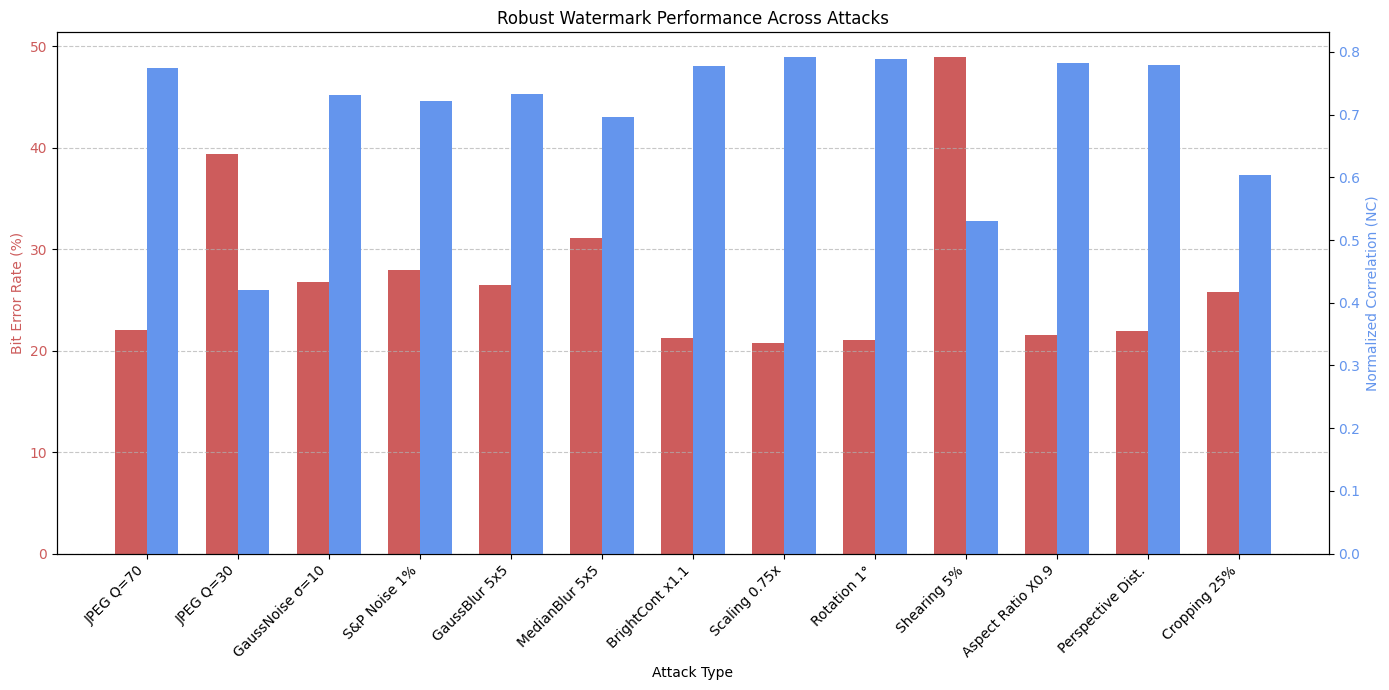

  [FAILURE] Could not recover message.
Saved fragile performance summary graph to fragile_performance_summary.png


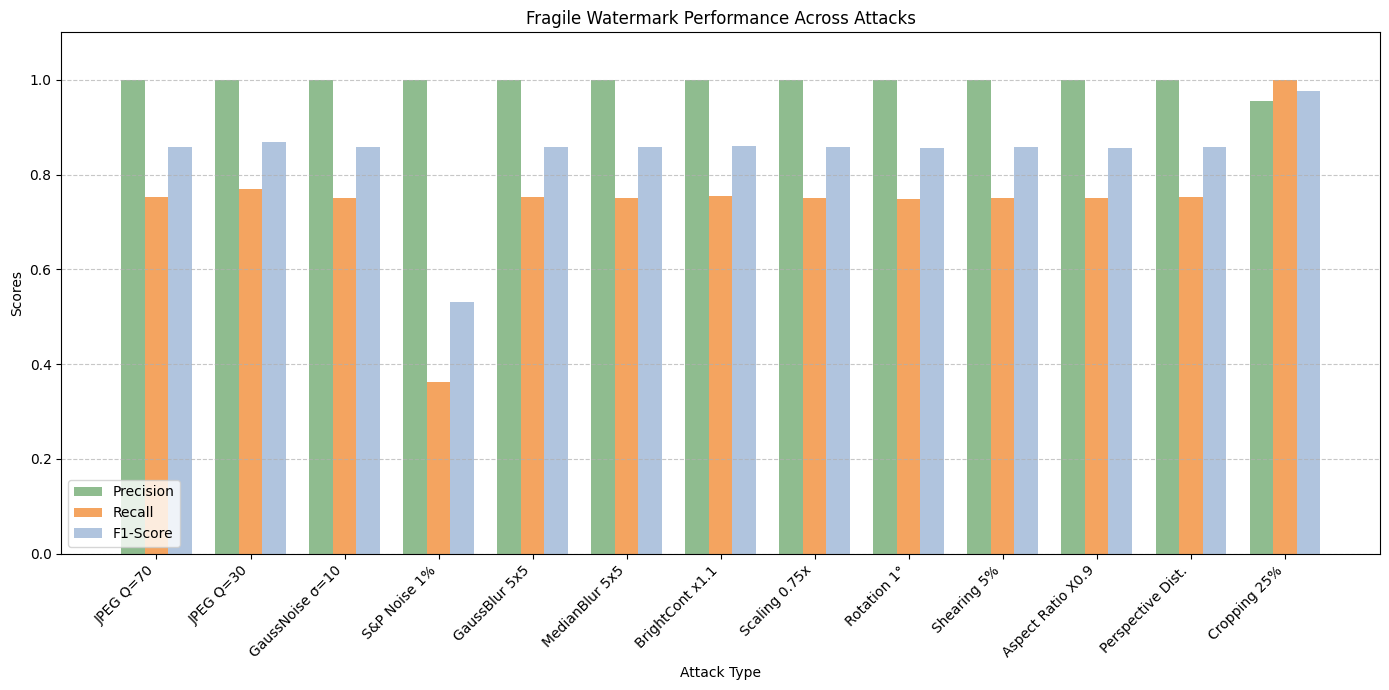

In [2]:
# === Main Application (Example Usage for Paper) ===
def calculate_nc(original_bits: np.ndarray, extracted_bits: np.ndarray) -> float:
    """
    Calculates the Normalized Correlation (NC) between two binary sequences.
    """
    if original_bits.size != extracted_bits.size or original_bits.size == 0:
        return 0.0
    original_numerical = original_bits.astype(np.float64)
    extracted_numerical = extracted_bits.astype(np.float64)
    numerator = np.sum(original_numerical * extracted_numerical)
    denominator = np.sum(original_numerical ** 2)
    if denominator == 0:
        return 1.0 if numerator == 0 else 0.0
    return numerator / denominator

def calculate_fragile_metrics(ground_truth_map: np.ndarray, detected_map: np.ndarray) -> dict:
    """
    Calculates Precision, Recall, and F1-Score for tamper detection.
    Maps should be block-level (H/8, W/8).
    """
    y_true = (ground_truth_map.flatten() > 0).astype(int)
    y_pred = (detected_map.flatten() > 0).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', pos_label=1, zero_division=0
    )
    return {'precision': precision, 'recall': recall, 'f1_score': f1}
def attack_rotation(img: np.ndarray, angle: float) -> np.ndarray:
    """
    Rotates an image by a given angle and then rotates it back to simulate
    real-world rotation correction, which introduces interpolation artifacts.
    """
    if img is None: return img
    try:
        h, w = img.shape[:2]
        center = (w // 2, h // 2)
        # Rotate forward
        M_forward = cv2.getRotationMatrix2D(center, angle, 1.0)
        rotated = cv2.warpAffine(img, M_forward, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)
        # Rotate back
        M_backward = cv2.getRotationMatrix2D(center, -angle, 1.0)
        restored = cv2.warpAffine(rotated, M_backward, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)
        return restored
    except Exception as e:
        print(f"Error in Rotation attack: {e}. Returning original image.")
        return img

def attack_cropping(img: np.ndarray, crop_ratio: float) -> np.ndarray:
    """
    Crops out the center of an image, replacing it with black.
    Returns an image of the same original size.
    """
    if img is None: return img
    try:
        h, w = img.shape[:2]
        ch, cw = int(h * crop_ratio), int(w * crop_ratio) # crop height and width
        y1, x1 = (h - ch) // 2, (w - cw) // 2
        y2, x2 = y1 + ch, x1 + cw
        
        cropped_img = img.copy()
        cropped_img[y1:y2, x1:x2] = 0 # Set the cropped area to black
        return cropped_img
    except Exception as e:
        print(f"Error in Cropping attack: {e}. Returning original image.")
        return img
def attack_aspect_ratio(img: np.ndarray, ratio_x: float, ratio_y: float) -> np.ndarray:
    """
    Simulates StirMark aspect ratio modification (stretching/squashing).
    Resizes the image and then resizes it back to W,H to simulate the attack artifact.
    """
    if img is None: return img
    try:
        h, w = img.shape[:2]
        # Scale to new aspect ratio
        scaled = cv2.resize(img, (int(w * ratio_x), int(h * ratio_y)), interpolation=cv2.INTER_LINEAR)
        # Restore to original container size (which effectively tests synchronization)
        return cv2.resize(scaled, (w, h), interpolation=cv2.INTER_LINEAR)
    except Exception as e:
        print(f"Error in Aspect Ratio attack: {e}. Returning original image.")
        return img

def create_cropping_ground_truth(img_shape: tuple, block_size: int, crop_ratio: float) -> np.ndarray:
    """
    Creates a block-level ground truth map for a cropping attack.
    Blocks inside the crop area are marked as tampered (1), others are not (0).
    """
    h, w = img_shape[:2]
    h_blk, w_blk = h // block_size, w // block_size
    ground_truth = np.zeros((h_blk, w_blk), dtype=np.uint8)

    ch, cw = int(h * crop_ratio), int(w * crop_ratio)
    y1, x1 = (h - ch) // 2, (w - cw) // 2
    y2, x2 = y1 + ch, x1 + cw

    # Find which blocks are affected by the crop
    start_blk_y, start_blk_x = y1 // block_size, x1 // block_size
    end_blk_y, end_blk_x = (y2 + block_size - 1) // block_size, (x2 + block_size - 1) // block_size
    
    ground_truth[start_blk_y:end_blk_y, start_blk_x:end_blk_x] = 1
    return ground_truth
def plot_summary_graphs(attack_results: dict):
    """
    Generates and saves summary bar charts for robust and fragile performance.
    """
    attack_names = list(attack_results.keys())
    
    # --- Chart 1: Robust Watermark Performance (BER and NC) ---
    ber_values = [attack_results[name]['ber'] for name in attack_names]
    nc_values = [attack_results[name]['nc'] for name in attack_names]
    
    x = np.arange(len(attack_names))  # the label locations
    width = 0.35  # the width of the bars

    fig1, ax1 = plt.subplots(figsize=(14, 7))
    rects1 = ax1.bar(x - width/2, ber_values, width, label='BER (%)', color='indianred')
    
    # Instantiate a second axes that shares the same x-axis for NC
    ax2 = ax1.twinx()
    rects2 = ax2.bar(x + width/2, nc_values, width, label='NC', color='cornflowerblue')

    # Add some text for labels, title and axes ticks
    ax1.set_ylabel('Bit Error Rate (%)', color='indianred')
    ax2.set_ylabel('Normalized Correlation (NC)', color='cornflowerblue')
    ax1.set_xlabel('Attack Type')
    ax1.set_title('Robust Watermark Performance Across Attacks')
    ax1.set_xticks(x)
    ax1.set_xticklabels(attack_names, rotation=45, ha="right")
    ax1.tick_params(axis='y', labelcolor='indianred')
    ax2.tick_params(axis='y', labelcolor='cornflowerblue')
    ax1.grid(axis='y', linestyle='--', alpha=0.7)

    fig1.tight_layout()
    plt.savefig("robust_performance_summary.png", dpi=300)
    print("\nSaved robust performance summary graph to robust_performance_summary.png")
    plt.show()
    # 2. Attempt ECC Recovery (Application Layer Metric)
    decoded_msg, success = decode_ecc_payload(extracted_logo, unit_len)

    if success == 1.0 and decoded_msg == secret_msg:
        print(f"  [SUCCESS] Recovered: '{decoded_msg}' despite attack!")
    else:
        print(f"  [FAILURE] Could not recover message.")
    # --- Chart 2: Fragile Watermark Performance (Precision, Recall, F1-Score) ---
    precision_values = [attack_results[name]['precision'] for name in attack_names]
    recall_values = [attack_results[name]['recall'] for name in attack_names]
    f1_values = [attack_results[name]['f1'] for name in attack_names]
    
    width = 0.25 # the width of the bars

    fig2, ax = plt.subplots(figsize=(14, 7))
    rects1 = ax.bar(x - width, precision_values, width, label='Precision', color='darkseagreen')
    rects2 = ax.bar(x, recall_values, width, label='Recall', color='sandybrown')
    rects3 = ax.bar(x + width, f1_values, width, label='F1-Score', color='lightsteelblue')

    # Add some text for labels, title and axes ticks
    ax.set_ylabel('Scores')
    ax.set_xlabel('Attack Type')
    ax.set_title('Fragile Watermark Performance Across Attacks')
    ax.set_xticks(x)
    ax.set_xticklabels(attack_names, rotation=45, ha="right")
    ax.legend(loc='lower left')
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.set_ylim(0, 1.1) # Set y-axis limit to be just over 1.0

    fig2.tight_layout()
    plt.savefig("fragile_performance_summary.png", dpi=300)
    print("Saved fragile performance summary graph to fragile_performance_summary.png")
    plt.show()
if __name__ == "__main__":
    import os
    import glob
    import numpy as np
    import cv2
    import matplotlib.pyplot as plt
    from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim
    import time

    # --- Setup: Find images and create output folders ---
    dataset_path = "archive"
    image_paths_to_evaluate = glob.glob(os.path.join(dataset_path, "*.png"))

    if not image_paths_to_evaluate:
        print(f"Error: No images found in '{dataset_path}'. Please check the path.")
        exit()

    print(f"Found {len(image_paths_to_evaluate)} images. Starting FULL evaluation with all attacks...")

    output_dir_local_tamper = "visuals_local_tamper"
    output_dir_attacks = "visuals_attacks"
    os.makedirs(output_dir_local_tamper, exist_ok=True)
    os.makedirs(output_dir_attacks, exist_ok=True)

    # --- Setup: Data structures for collecting results ---
    attacks_to_run_config = [
        ("JPEG Q=70", lambda img: attack_jpeg_compression(img, 70), "global"),
        ("JPEG Q=30", lambda img: attack_jpeg_compression(img, 30), "global"),
        ("GaussNoise σ=10", lambda img: attack_gaussian_noise(img, 10), "global"),
        ("S&P Noise 1%", lambda img: attack_salt_pepper_noise(img, 0.01), "global"),
        ("GaussBlur 5x5", lambda img: attack_gaussian_blur(img, 5, 1.5), "global"),
        ("MedianBlur 5x5", lambda img: attack_median_blur(img, 5), "global"),
        ("BrightCont x1.1", lambda img: attack_brightness_contrast(img, 1.1, 10), "global"),
        ("Scaling 0.75x", lambda img: attack_scaling(img, 0.75), "global"),
        ("Rotation 1°", lambda img: attack_rotation(img, 1.0), "global"),
        ("Shearing 5%", lambda img: attack_shearing(img, 0.05), "global"),
        ("Aspect Ratio X0.9", lambda img: attack_aspect_ratio(img, 0.9, 1.0), "global"), # NEW ATTACK
        ("Perspective Dist.", lambda img: attack_perspective_distortion(img, 0.02), "global"), 
        ("Cropping 25%", lambda img: attack_cropping(img, 0.5), "local"),
    ]
    # This dictionary will hold lists of metric values for each attack
    per_attack_results = {name: {'ber': [], 'nc': [], 'precision': [], 'recall': [], 'f1': []} for name, _, _ in attacks_to_run_config}
    
    # These lists will hold the overall non-attack metrics
    overall_psnr, overall_ssim, overall_embedding_time = [], [], []

    # --- Main Loop: Process each image in the dataset ---
    for idx, image_path in enumerate(image_paths_to_evaluate):
        image_basename = os.path.basename(image_path)
        image_name_no_ext = os.path.splitext(image_basename)[0]
        print(f"\n--- [{idx+1}/{len(image_paths_to_evaluate)}] Processing: {image_basename} ---")

        # Load image
        orig_bgr = cv2.imread(image_path)
        if orig_bgr is None:
            print("  Could not load image. Skipping.")
            continue
        orig_rgb_u8 = cv2.cvtColor(orig_bgr, cv2.COLOR_BGR2RGB)

        # Check image size
        nblocks_img = (orig_rgb_u8.shape[0] // BLOCK_SIZE) * (orig_rgb_u8.shape[1] // BLOCK_SIZE)
        if nblocks_img == 0:
            print("  Image too small. Skipping.")
            continue

        # Create watermark data
        secret_msg = "COPYRIGHT_2025_HarshitL" 

        # Generate the robust payload
        # This payload now has structure (ECC) that resists attacks!
        logo_data, unit_len = generate_ecc_payload(secret_msg, nblocks_img)

        print(f"  Embedding ECC-protected payload (Len: {len(logo_data)} bits)...")
        wm_robust_image = embed_robust_dct(orig_rgb_u8, logo_data)

        # Embed watermarks and measure performance
        print("  Embedding watermarks...")
        wm_robust_image = embed_robust_dct(orig_rgb_u8, logo_data)
        s_time = time.time()
        wm_final_image, _ = embed_fragile_dct(wm_robust_image)
        e_time = time.time()

        # Store non-attack metrics
        embedding_time = e_time - s_time
        psnr_val = psnr(orig_rgb_u8, wm_final_image, data_range=255)
        ssim_val = ssim(cv2.cvtColor(orig_rgb_u8, cv2.COLOR_RGB2GRAY), cv2.cvtColor(wm_final_image, cv2.COLOR_RGB2GRAY), data_range=255)
        overall_embedding_time.append(embedding_time)
        overall_psnr.append(psnr_val)
        overall_ssim.append(ssim_val)
        print(f"  Done. PSNR: {psnr_val:.2f} dB, SSIM: {ssim_val:.4f}, Time: {embedding_time:.2f}s")

        # Generate and save the "Local Tamper" visualization for the current image
        img_for_local_tamper = wm_final_image.copy()
        tam_y, tam_x = img_for_local_tamper.shape[0] // 2, img_for_local_tamper.shape[1] // 2
        img_for_local_tamper[tam_y:tam_y + BLOCK_SIZE, tam_x:tam_x + BLOCK_SIZE] = np.random.randint(0, 256, size=(BLOCK_SIZE, BLOCK_SIZE, 3), dtype=np.uint8)
        tamper_map_local = detect_fragile_dct(img_for_local_tamper)

        fig_local, axes_local = plt.subplots(1, 3, figsize=(12, 4))
        axes_local[0].imshow(wm_final_image)
        axes_local[0].set_title("Watermarked")
        axes_local[0].axis('off')
        axes_local[0].text(0, wm_final_image.shape[0] + 15, f"PSNR: {psnr_val:.2f} dB\nSSIM: {ssim_val:.4f}", fontsize=9)
        axes_local[1].imshow(img_for_local_tamper)
        axes_local[1].set_title("Local Tamper")
        axes_local[1].axis('off')
        axes_local[2].imshow(tamper_map_local, cmap='gray')
        axes_local[2].set_title("Tamper Map")
        axes_local[2].axis('off')
        fig_local.suptitle(f"Local Tamper Example: {image_basename}", fontsize=14)
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.savefig(os.path.join(output_dir_local_tamper, f"local_tamper_{image_name_no_ext}.png"), dpi=150)
        plt.close(fig_local)

        # --- Attack Evaluation & Visualization Loop ---
        attack_visual_data = []
        for attack_name, attack_func, attack_type in attacks_to_run_config:
            # 1. Apply the Attack (Do this once at the top)
            attacked_image = attack_func(wm_final_image.copy())
            if attacked_image is None: continue

            # --- ROBUSTNESS CHECK ---
            current_nc = 0.0
            current_ber = 50.0 # Default to failure (0.5 BER)
            
            # 2. Determine Robust Metrics (Branch based on attack type)
            # 2. Determine Robust Metrics (Branch based on attack type)
            if "Shearing" in attack_name:
                print(f"    [Sync] Running Search for {attack_name}...")
                best_nc, best_ber = synchronization_search(attacked_image, logo_data, "Shearing")
                current_nc = best_nc
                current_ber = best_ber
                
            elif "Rotation" in attack_name:
                print(f"    [Sync] Running Search for {attack_name}...")
                best_nc, best_ber = synchronization_search(attacked_image, logo_data, "Rotation")
                current_nc = best_nc
                current_ber = best_ber

            elif "Perspective" in attack_name:
                print(f"    [Sync] Running Search for {attack_name}...")
                best_nc, best_ber = synchronization_search(attacked_image, logo_data, "Perspective")
                current_nc = best_nc
                current_ber = best_ber

            elif "Aspect" in attack_name:
                print(f"    [Sync] Running Search for {attack_name}...")
                best_nc, best_ber = synchronization_search(attacked_image, logo_data, "AspectRatio")
                current_nc = best_nc
                current_ber = best_ber
                
            else:
                # Standard Extraction
                extracted_logo = extract_robust_dct(attacked_image, len(logo_data))
                len_comp = min(len(logo_data), len(extracted_logo))
                if len_comp > 0:
                    diff = np.sum(logo_data[:len_comp] != extracted_logo[:len_comp])
                    current_ber = (diff / len_comp) * 100
                    current_nc = calculate_nc(logo_data[:len_comp], extracted_logo[:len_comp])
            # 3. STORE ROBUST METRICS (Un-indented: Runs for ALL attacks)
            per_attack_results[attack_name]['ber'].append(current_ber)
            per_attack_results[attack_name]['nc'].append(current_nc)

            # 4. FRAGILE METRICS & VISUALIZATION (Un-indented: Runs for ALL attacks)
            h_blk, w_blk = (wm_final_image.shape[0] // BLOCK_SIZE, wm_final_image.shape[1] // BLOCK_SIZE)
            
            if attack_type == "global":
                ground_truth_tamper_map = np.ones((h_blk, w_blk), dtype=np.uint8)
            elif attack_type == "local":
                ground_truth_tamper_map = create_cropping_ground_truth(wm_final_image.shape, BLOCK_SIZE, 0.5)

            detected_map_full = detect_fragile_dct(attacked_image)
            detected_map_block = cv2.resize(detected_map_full, (w_blk, h_blk), interpolation=cv2.INTER_NEAREST)
            
            fragile_metrics = calculate_fragile_metrics(ground_truth_tamper_map, detected_map_block)
            per_attack_results[attack_name]['precision'].append(fragile_metrics['precision'])
            per_attack_results[attack_name]['recall'].append(fragile_metrics['recall'])
            per_attack_results[attack_name]['f1'].append(fragile_metrics['f1_score'])

            attack_visual_data.append({
                "name": attack_name, 
                "attacked_image": attacked_image, 
                "tamper_map": detected_map_full
            })

        # Generate and save the "Attack Robustness" visualization for the current image
        if attack_visual_data:
            num_attacks_plot = len(attack_visual_data)
            fig_attacks, axes_attacks = plt.subplots(num_attacks_plot, 3, figsize=(12, 2.5 * num_attacks_plot))
            if num_attacks_plot == 1: axes_attacks = np.array([axes_attacks])
            for i, data in enumerate(attack_visual_data):
                axes_attacks[i, 0].imshow(data["attacked_image"])
                axes_attacks[i, 0].set_title(f"{data['name']}\nAttacked Image", fontsize=8)
                axes_attacks[i, 0].axis('off')
                axes_attacks[i, 1].imshow(data["tamper_map"], cmap='gray')
                axes_attacks[i, 1].set_title("Tamper Map", fontsize=8)
                axes_attacks[i, 1].axis('off')
                axes_attacks[i, 2].imshow(wm_final_image)
                axes_attacks[i, 2].set_title("Original Watermarked", fontsize=8)
                axes_attacks[i, 2].axis('off')
            fig_attacks.suptitle(f"Robustness Evaluation under Attacks: {image_basename}", fontsize=14)
            plt.tight_layout(rect=[0, 0.03, 1, 0.95])
            plt.savefig(os.path.join(output_dir_attacks, f"attacks_{image_name_no_ext}.png"), dpi=300)
            plt.close(fig_attacks)

    # --- FINAL STEP: Calculate Final Averages and Generate Summary Graphs ---
    final_attack_averages = {name: {} for name, _, _ in attacks_to_run_config}
    for attack_name in per_attack_results:
        for metric in per_attack_results[attack_name]:
            final_attack_averages[attack_name][metric] = np.mean(per_attack_results[attack_name][metric])

    # Print the final numeric summary table
    print("\n" + "=" * 70)
    print(f"OVERALL RESULTS FOR {len(image_paths_to_evaluate)} IMAGES")
    print("=" * 70)
    print(f"{'Average Embedding Time':<25}: {np.mean(overall_embedding_time):.3f}s")
    print(f"{'Average PSNR':<25}: {np.mean(overall_psnr):.2f} dB")
    print(f"{'Average SSIM':<25}: {np.mean(overall_ssim):.4f}")
    print("\n--- Average Attack Performance ---")
    
    # Calculate overall averages for printing
    overall_avg_ber = np.mean([final_attack_averages[name]['ber'] for name in final_attack_averages])
    overall_avg_nc = np.mean([final_attack_averages[name]['nc'] for name in final_attack_averages])
    overall_avg_f1 = np.mean([final_attack_averages[name]['f1'] for name in final_attack_averages])
    overall_avg_precision = np.mean([final_attack_averages[name]['precision'] for name in final_attack_averages])
    overall_avg_recall = np.mean([final_attack_averages[name]['recall'] for name in final_attack_averages])
    
    print(f"{'Average Robust BER':<25}: {overall_avg_ber:.2f}%")
    print(f"{'Average Robust NC':<25}: {overall_avg_nc:.3f}")
    print(f"{'Average Fragile F1-Score':<25}: {overall_avg_f1:.3f}")
    print(f"  {'└─ Average Precision':<23}: {overall_avg_precision:.3f}")
    print(f"  {'└─ Average Recall':<23}: {overall_avg_recall:.3f}")
    print("=" * 70)

    # Call the function to plot the summary graphs
    plot_summary_graphs(final_attack_averages)

In [ ]:
# --- PRINT LATEX TABLE FOR PAPER ---
print("\n" + "="*30 + " LATEX TABLE DATA " + "="*30)
print("Copy-paste this into your Table I in the manuscript:\n")
    
print(r"\begin{table*}[ht]")
print(r"\centering")
print(r"\caption{Robustness and Tamper Localization Results (Averaged over 24 Kodak Images)}")
print(r"\label{tab:results}")
print(r"\begin{tabular}{lccccc}")
print(r"\hline")
print(r"\textbf{Attack Type} & \textbf{BER (\%)} & \textbf{NC} & \textbf{Precision} & \textbf{Recall} & \textbf{F1-Score} \\ \hline")
    
for name in attacks_to_run_config:
    att_name = name[0] # Extract name string
    metrics = final_attack_averages[att_name]
        
    # Format: Name & BER & NC & Prec & Rec & F1 \\
    row_str = f"{att_name} & {metrics['ber']:.2f} & {metrics['nc']:.3f} & {metrics['precision']:.3f} & {metrics['recall']:.3f} & {metrics['f1']:.3f} \\\\"
    print(row_str)
        
print(r"\hline")
print(f"\\textbf{{Average}} & \\textbf{{{overall_avg_ber:.2f}}} & \\textbf{{{overall_avg_nc:.3f}}} & \\textbf{{{overall_avg_precision:.3f}}} & \\textbf{{{overall_avg_recall:.3f}}} & \\textbf{{{overall_avg_f1:.3f}}} \\\\")
print(r"\hline")
print(r"\end{tabular}")
print(r"\end{table*}")
print("="*80)